In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

df = pd.read_csv(r"C:\Users\KDS-22\Desktop\Project\data\processed\02_의료기관1_v3.csv")

print(df.head())

    지역  65세이상  고령인구비율  의료기관수  공공 기관 수  고령인구1000명당의료기관수
0   동면   1020   54.72      0        2             0.00
1  수신면    946   47.73      0        2             0.00
2  성남면   1328   48.57      0        3             0.00
3  광덕면   1857   47.01      0        3             0.00
4  일봉동   4144   17.11      1        0             0.24


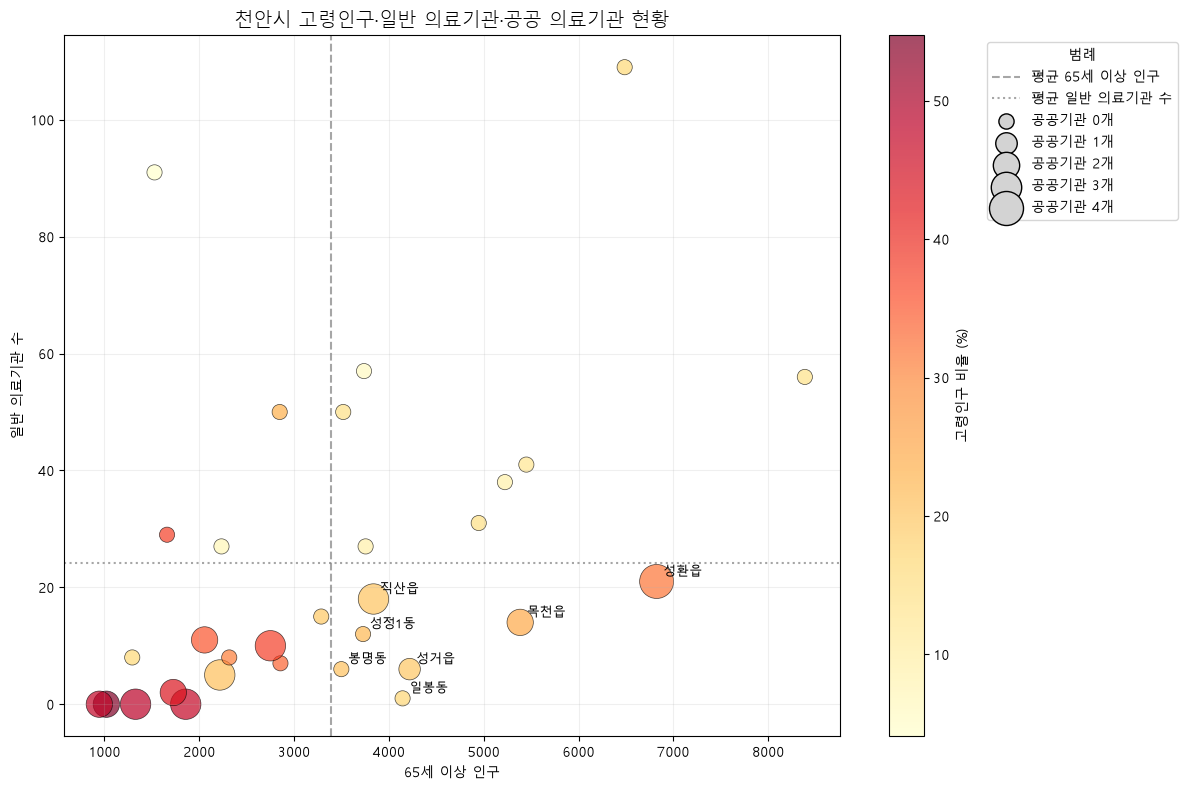

In [4]:
matplotlib.rc("font", family="Malgun Gothic")
plt.rcParams["axes.unicode_minus"] = False

bubble_df = df[
    [
        "지역",
        "65세이상",
        "고령인구비율",
        "의료기관수",
        "공공 기관 수"
    ]
].copy()

avg_old = bubble_df["65세이상"].mean()
avg_med = bubble_df["의료기관수"].mean()

bubble_size = (bubble_df["공공 기관 수"] + 1) * 120

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    bubble_df["65세이상"],          
    bubble_df["의료기관수"],        
    s=bubble_size,                  
    c=bubble_df["고령인구비율"],    
    cmap="YlOrRd",
    alpha=0.7,
    edgecolors="black",
    linewidth=0.5
)

plt.axvline(
    avg_old,
    color="gray",
    linestyle="--",
    alpha=0.7,
    label="평균 65세 이상 인구"
)

plt.axhline(
    avg_med,
    color="gray",
    linestyle=":",
    alpha=0.7,
    label="평균 일반 의료기관 수"
)

priority_mask = (
    (bubble_df["65세이상"] >= avg_old) &
    (bubble_df["의료기관수"] < avg_med)
)

priority_df = bubble_df[priority_mask]

for _, row in priority_df.iterrows():
    plt.text(
        row["65세이상"] + 70,
        row["의료기관수"] + 1,
        row["지역"],
        fontsize=9
    )

colorbar = plt.colorbar(scatter)
colorbar.set_label("고령인구 비율 (%)")

for count in [0, 1, 2, 3, 4]:
    plt.scatter(
        [],
        [],
        s=(count + 1) * 120,
        color="lightgray",
        edgecolors="black",
        label=f"공공기관 {count}개"
    )


plt.title(
    "천안시 고령인구·일반 의료기관·공공 의료기관 현황",
    fontsize=14
)
plt.xlabel("65세 이상 인구")
plt.ylabel("일반 의료기관 수")

plt.grid(alpha=0.2)
plt.legend(
    title="범례",
    bbox_to_anchor=(1.18, 1),
    loc="upper left"
)

plt.tight_layout()


plt.savefig(
    "천안시 고령인구·일반 의료기관·공공 의료기관 현황.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [5]:
priority_result = df[
    (df["65세이상"] >= df["65세이상"].mean()) &
    (df["의료기관수"] < df["의료기관수"].mean())
].copy()

priority_result = priority_result[
    [
        "지역",
        "65세이상",
        "고령인구비율",
        "의료기관수",
        "공공 기관 수",
        "고령인구1000명당의료기관수"
    ]
].sort_values(
    "고령인구1000명당의료기관수",
    ascending=True
)

print(priority_result)

      지역  65세이상  고령인구비율  의료기관수  공공 기관 수  고령인구1000명당의료기관수
4    일봉동   4144   17.11      1        0             0.24
8    성거읍   4218   19.83      6        1             1.42
7    봉명동   3498   20.52      6        0             1.72
15   목천읍   5384   24.79     14        2             2.60
18   성환읍   6823   31.84     21        4             3.08
14  성정1동   3727   22.21     12        0             3.22
17   직산읍   3837   20.24     18        3             4.69


In [9]:
df["의료기관수"].describe()

count     31.000000
mean      24.193548
std       26.843273
min        0.000000
25%        6.000000
50%       14.000000
75%       34.500000
max      109.000000
Name: 의료기관수, dtype: float64

In [11]:
iqr = 34.5 - 6
iqr = iqr * 1.5

print(6 - iqr)
print(34.5 + iqr)

-36.75
77.25
